Step 1 : Machine Learning Models

Task 1.1 - Load and Explore

In [ ]:
import kagglehub
import os

In [ ]:
import kagglehub

path = kagglehub.dataset_download("iasadpanwhar/parking-lot-detection-counter")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'parking-lot-detection-counter' dataset.
Path to dataset files: /kaggle/input/parking-lot-detection-counter


In [ ]:
print(os.listdir(path))

['parking']


In [ ]:
print(os.listdir(path + "/parking"))

['model', 'mask_crop.png', 'parking_1920_1080_loop.mp4', 'mask_1920_1080.png', 'clf-data', 'parking_crop_loop.mp4', 'parking_1920_1080.mp4', 'util.py', 'parking_crop.mp4']


In [ ]:
import pandas as pd

empty_files = os.listdir(path + "/parking/clf-data/empty")
not_empty_files = os.listdir(path + "/parking/clf-data/not_empty")

data = []

for file in empty_files:
    data.append([file, "empty"])

for file in not_empty_files:
    data.append([file, "not_empty"])

df = pd.DataFrame(data, columns=["image_name", "label"])

df.head()

,image_name,label
0,00000610_00000385.jpg,empty
1,00000590_00000180.jpg,empty
2,00000080_00000164.jpg,empty
3,00000060_00000281.jpg,empty
4,00000590_00000089.jpg,empty


In [ ]:
print(df.shape)

(6090, 2)


In [ ]:
print(df.isnull().sum())

image_name    0
label         0
dtype: int64


In [ ]:
print(df['label'].value_counts())

label
empty        3045
not_empty    3045
Name: count, dtype: int64


The dataset is balanced between the two classes.

Task 1.2 - Prepare the Data

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df["image_name"]
y = df["label"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(4872,) (1218,)
label
not_empty    2436
empty        2436
Name: count, dtype: int64
label
empty        609
not_empty    609
Name: count, dtype: int64


Task 1.3 - Train and Compare Models

In [ ]:
import cv2
import numpy as np

images = []
labels = []

for file in empty_files:
    img_path = path + "/parking/clf-data/empty/" + file

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (64, 64))

    images.append(img.flatten())
    labels.append(0)

for file in not_empty_files:
    img_path = path + "/parking/clf-data/not_empty/" + file

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (64, 64))

    images.append(img.flatten())
    labels.append(1)

X = np.array(images)
y = np.array(labels)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

lr_model = LogisticRegression(max_iter=1000)
rf_model = RandomForestClassifier(random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=3)

lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)
knn_preds = knn_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
rf_train_preds = rf_model.predict(X_train)
rf_train_accuracy = accuracy_score(y_train, rf_train_preds)

rf_test_accuracy = accuracy_score(y_test, rf_preds)

print("Random Forest Training Accuracy:", rf_train_accuracy)
print("Random Forest Test Accuracy:", rf_test_accuracy)

Random Forest Training Accuracy: 1.0
Random Forest Test Accuracy: 1.0


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, lr_preds))
print("Precision:", precision_score(y_test, lr_preds))
print("Recall:", recall_score(y_test, lr_preds))
print("F1-score:", f1_score(y_test, lr_preds))

print()

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print("Precision:", precision_score(y_test, rf_preds))
print("Recall:", recall_score(y_test, rf_preds))
print("F1-score:", f1_score(y_test, rf_preds))

print()

print("KNN")
print("Accuracy:", accuracy_score(y_test, knn_preds))
print("Precision:", precision_score(y_test, knn_preds))
print("Recall:", recall_score(y_test, knn_preds))
print("F1-score:", f1_score(y_test, knn_preds))

Logistic Regression
Accuracy: 0.9811165845648604
Precision: 1.0
Recall: 0.9622331691297209
F1-score: 0.9807531380753138

Random Forest
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0

KNN
Accuracy: 0.9991789819376026
Precision: 1.0
Recall: 0.9983579638752053
F1-score: 0.9991783073130649


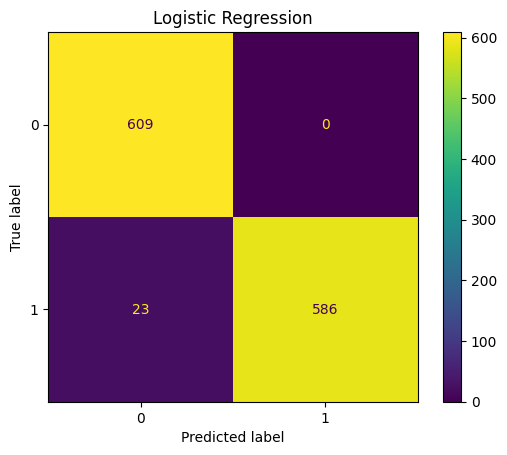

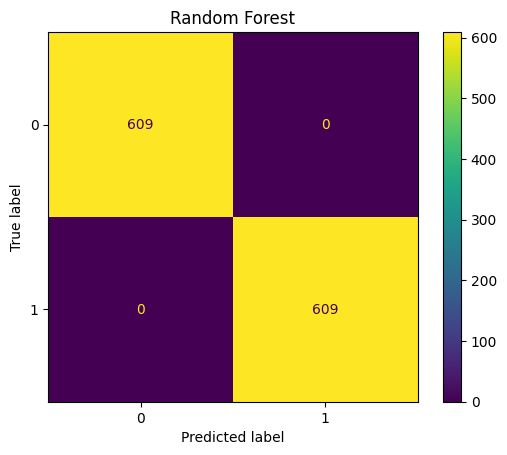

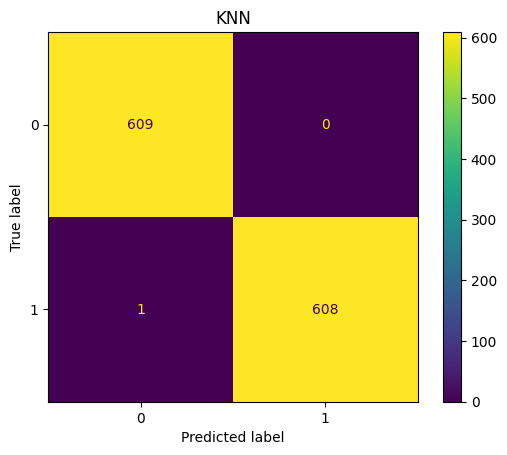

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Logistic Regression")
plt.show()

cm = confusion_matrix(y_test, rf_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Random Forest")
plt.show()

cm = confusion_matrix(y_test, knn_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("KNN")
plt.show()

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "KNN"],

    "Accuracy": [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, knn_preds)
    ],

    "Precision": [
        precision_score(y_test, lr_preds),
        precision_score(y_test, rf_preds),
        precision_score(y_test, knn_preds)
    ],

    "Recall": [
        recall_score(y_test, lr_preds),
        recall_score(y_test, rf_preds),
        recall_score(y_test, knn_preds)
    ],

    "F1-score": [
        f1_score(y_test, lr_preds),
        f1_score(y_test, rf_preds),
        f1_score(y_test, knn_preds)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.981117        1.0  0.962233  0.980753
1        Random Forest  1.000000        1.0  1.000000  1.000000
2                  KNN  0.999179        1.0  0.998358  0.999178


In [ ]:
print("Random Forest was chosen as the best model because it achieved the highest accuracy and F1-score.")

Random Forest was chosen as the best model because it achieved the highest accuracy and F1-score.


Step 2: Neural Network

Task 2.1 - Build and Train

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
X_train_nn = X_train / 255.0
X_test_nn = X_test / 255.0

In [ ]:
model = Sequential([

    Dense(128, activation='relu', input_shape=(4096,)),

    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train_nn,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8186 - loss: 0.4353 - val_accuracy: 0.9221 - val_loss: 0.2314
Epoch 2/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9197 - loss: 0.2421 - val_accuracy: 0.9497 - val_loss: 0.1190
Epoch 3/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9371 - loss: 0.1801 - val_accuracy: 0.9703 - val_loss: 0.0794
Epoch 4/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9554 - loss: 0.1304 - val_accuracy: 0.9692 - val_loss: 0.0779
Epoch 5/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9515 - loss: 0.1457 - val_accuracy: 0.9744 - val_loss: 0.0861
Epoch 6/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9659 - loss: 0.1037 - val_accuracy: 0.9877 - val_loss: 0.0344
Epoch 7/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9756 - loss: 0.0781 - val_accuracy: 0.9877 - val_loss: 0.0306
Epoch 8/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9749 - loss: 0.0727 - val_accuracy

In [ ]:
import matplotlib.pyplot as plt

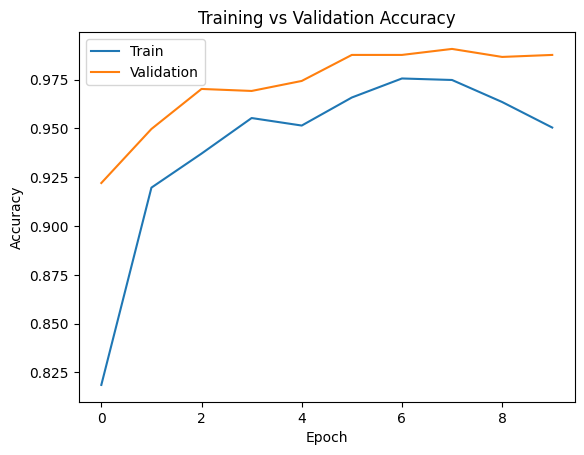

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Training vs Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

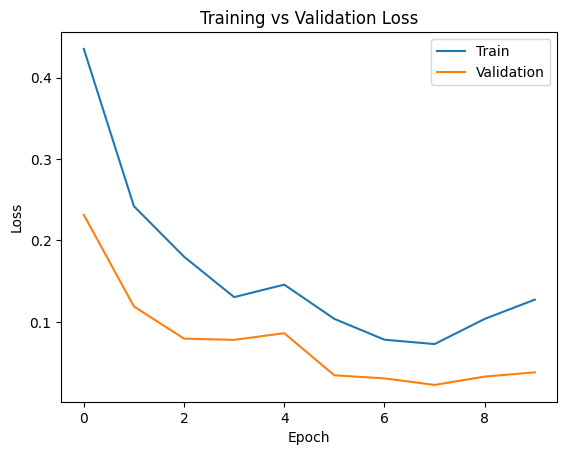

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Training vs Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

Task 2.2 - Compare with Step 1

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

In [ ]:
probs = model.predict(X_test_nn)

nn_preds = (probs > 0.5).astype(int)

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
nn_accuracy = accuracy_score(y_test, nn_preds)
nn_precision = precision_score(y_test, nn_preds)
nn_recall = recall_score(y_test, nn_preds)
nn_f1 = f1_score(y_test, nn_preds)

print("Accuracy:", nn_accuracy)
print("Precision:", nn_precision)
print("Recall:", nn_recall)
print("F1-score:", nn_f1)

Accuracy: 0.9885057471264368
Precision: 1.0
Recall: 0.9770114942528736
F1-score: 0.9883720930232558


In [ ]:
results.loc[len(results)] = [
    "Neural Network",
    nn_accuracy,
    nn_precision,
    nn_recall,
    nn_f1
]

print(results)

                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.981117        1.0  0.962233  0.980753
1        Random Forest  1.000000        1.0  1.000000  1.000000
2                  KNN  0.999179        1.0  0.998358  0.999178
3       Neural Network  0.988506        1.0  0.977011  0.988372


The Random Forest model achieved the highest accuracy score, with perfect performance on both the training and test sets (1.0). This indicates that the model generalizes well on this dataset, with no signs of overfitting observed in this experiment.

The Neural Network achieved strong and stable performance, and the training and validation curves showed consistent learning behavior with the help of the Dropout layer. Therefore, the Neural Network may still be considered reliable for unseen data due to its stable generalization performance.